Download [dataset](https://www.kaggle.com/competitions/platesv2)

Place it in `/data`

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

torch.random.manual_seed(42)
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"
learning_rate = 1e-3
batch_size = 16
epochs = 50

device

device(type='cuda')

in test: *Dirty* - $392$, *Clean* - $208$

In [79]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [80]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class TrainDataset(Dataset):
    def __init__(self, path, transform=None):
        self.transform = transform
        self.data = []
        self.labels = []

        for file in os.listdir(os.path.join(path, 'cleaned')):
            path_to_file = os.path.join(path, 'cleaned', file)
            image = Image.open(path_to_file).convert("RGB")
            self.data.append(image)
            # Class index 0 = clean (matches submission: argmax 0 -> "clean")
            self.labels.append(0)

        for file in os.listdir(os.path.join(path, 'dirty')):
            path_to_file = os.path.join(path, 'dirty', file)
            image = Image.open(path_to_file).convert("RGB")
            self.data.append(image)
            self.labels.append(1)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if self.transform is not None:
            return self.transform(self.data[idx]), self.labels[idx]
        else:
            return self.data[idx], self.labels[idx]

class TestDataset(Dataset):
    def __init__(self, path, transform=None):
        self.transform = transform
        self.data = []
        for file in sorted(os.listdir(path)):
            path_to_file = os.path.join(path, file)
            image = Image.open(path_to_file).convert("RGB")
            self.data.append(image)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]
        if self.transform is not None:
            img = self.transform(img)
        return img


train_path = r"./data/train"
test_path = r"./data/test"

train_loader = DataLoader(TrainDataset(train_path, train_transform), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TestDataset(test_path, test_transform), batch_size=batch_size, shuffle=False)

In [81]:
import torch.nn as nn

backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

for param in backbone.parameters():
    param.requires_grad = False

class DINOv2Classifier(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(backbone.embed_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x)
        return self.head(features)

model = DINOv2Classifier(backbone, num_classes=2)

backbone_params = list(model.backbone.parameters())
head_params = list(model.head.parameters())

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": 1e-5, "weight_decay": 0.01},
        {"params": head_params, "lr": 1e-3, "weight_decay": 0.0},
    ]
)

Using cache found in C:\Users\andre/.cache\torch\hub\facebookresearch_dinov2_main


In [82]:
from trainer import Trainer

trainer = Trainer(model, criterion, optimizer, device, epoch_amount=epochs)

In [83]:
trainer.fit(train_loader)

Эпоха: 0 Loss_train: 0.7581710815429688, 0:00:00.468768 сек

Эпоха: 1 Loss_train: 0.5116996765136719, 0:00:00.397282 сек

Эпоха: 2 Loss_train: 0.3905283610026042, 0:00:00.345030 сек

Эпоха: 3 Loss_train: 0.2514762878417969, 0:00:00.272212 сек

Эпоха: 4 Loss_train: 0.19686039288838705, 0:00:00.263494 сек

Эпоха: 5 Loss_train: 0.24471195538838705, 0:00:00.275942 сек

Эпоха: 6 Loss_train: 0.16246914863586426, 0:00:00.271165 сек

Эпоха: 7 Loss_train: 0.20248095194498697, 0:00:00.275857 сек

Эпоха: 8 Loss_train: 0.10646649201711018, 0:00:00.261336 сек

Эпоха: 9 Loss_train: 0.09075778722763062, 0:00:00.290253 сек

Эпоха: 10 Loss_train: 0.11614333093166351, 0:00:00.294045 сек

Эпоха: 11 Loss_train: 0.07856810092926025, 0:00:00.294980 сек

Эпоха: 12 Loss_train: 0.06882035732269287, 0:00:00.294015 сек

Эпоха: 13 Loss_train: 0.07907010118166606, 0:00:00.266872 сек

Эпоха: 14 Loss_train: 0.050534844398498535, 0:00:00.305875 сек

Эпоха: 15 Loss_train: 0.06264610836903255, 0:00:00.301997 сек

Эпоха

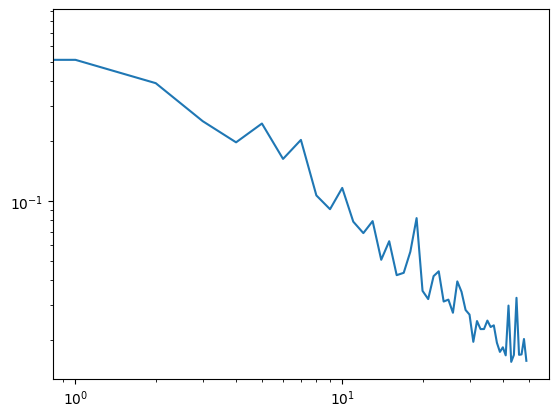

In [84]:
plt.loglog(trainer.train_loss)
plt.show()

In [85]:
trainer.save("./model.pt")

In [86]:
predictions = trainer.predict(test_loader)

In [87]:
pred_class = predictions.argmax(dim=1).numpy()
labels_sub = np.where(pred_class == 0, "clean", "dirty")

submission = pd.DataFrame({
    "id": [f"{i:04d}" for i in range(len(pred_class))],
    "label": labels_sub,
})
submission.to_csv("./data/submission.csv", index=False)

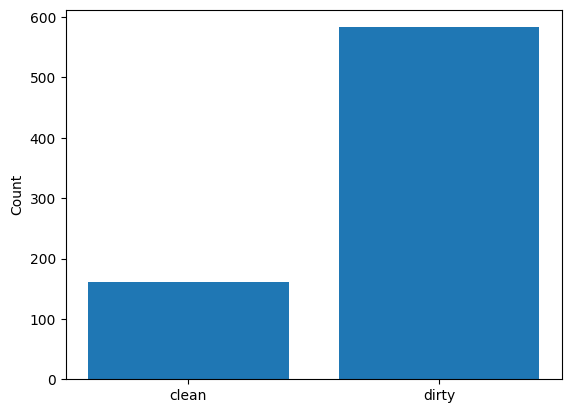

In [88]:
counts = np.bincount(pred_class)
plt.bar(["clean", "dirty"], counts)
plt.ylabel("Count")
plt.show()